# 080 — Analyze named events and independent video timing

Measure named-event pressure amplitudes and export the exact source times,
predicted reference-channel arrivals, waveform windows, baselines and signal
intervals used by downstream manuscript and figure notebooks.

Positive, negative, peak-to-peak and 1-km-reduced pressure are
measured from the canonical Notebook 010 moving-median-baseline-corrected pressure
Stream. Each manually reviewed window is expressed relative to the predicted DD2
arrival calculated from the canonical source time and a declared 351 m s⁻¹
propagation speed. Short local baseline intervals remove residual constant offsets.

The MEDIAN row is the median of independently measured sensor extrema, not
the extrema of a median waveform. These broad, manually adopted windows can
include neighboring pulses and coda; canonical source times locate the windows
but do not independently validate pulse identity. No phase boundaries are
defined or changed here.


This compact notebook provides the named-event measurements used
in manuscript text and figure annotations. It remains separate from Notebook 070
because these windows are manually reviewed for a few physically important
arrivals rather than derived from the full event catalogue.


In [1]:
from pathlib import Path
import json
import sys
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
from obspy import Stream, UTCDateTime

def find_project_root(start):
    current = Path(start).resolve()
    for candidate in (current, *current.parents):
        if (candidate / "modules" / "project_config.py").is_file():
            return candidate
    raise FileNotFoundError(
        f"Could not find modules/project_config.py above {current}"
    )


project_root = find_project_root(Path.cwd())
project_root_text = str(project_root)
sys.path = [entry for entry in sys.path if entry != project_root_text]
sys.path.insert(0, project_root_text)

# A long-lived Jupyter kernel may still hold an older project_config after
# the file has been edited. Remove the cached package and import the copy
# belonging to the repository that contains this notebook.
sys.modules.pop("modules.project_config", None)
sys.modules.pop("modules", None)
importlib.invalidate_caches()
from modules import project_config as config

expected_config_file = (
    project_root / "modules" / "project_config.py"
).resolve()
active_config_file = Path(config.__file__).resolve()
if active_config_file != expected_config_file:
    raise RuntimeError(
        "Imported the wrong project_config.py: "
        f"{active_config_file}; expected {expected_config_file}"
    )
DERIVED_DIR = config.NB080_DIR
FIGURE_DIR = config.NB080_DIR
DERIVED_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "figure.dpi": 120,
})


In [2]:
from obspy import read
from modules.event_measurements import (
    measure_reduced_pressures_in_window,
    pressure_results_for_paper,
)

ANALYSIS_CONFIG_FILE = (
    config.NB010_DIR / "analysis_configuration.json"
)

if not ANALYSIS_CONFIG_FILE.exists():
    raise FileNotFoundError(ANALYSIS_CONFIG_FILE)

analysis_config = json.loads(
    ANALYSIS_CONFIG_FILE.read_text()
)

GEOMETRY_FILE = Path(
    analysis_config["geometry_file"]
).expanduser()

if not GEOMETRY_FILE.exists():
    raise FileNotFoundError(
        "Geometry product recorded by Notebook 010 was not found: "
        f"{GEOMETRY_FILE}"
    )

baseline_products = analysis_config.get(
    "baseline_removed_streams",
    {},
)
BASELINE_STREAM_FILE = Path(
    baseline_products.get(
        "pickle",
        config.NB010_DIR
        / "bchh_corrected_moving_median_baseline_removed.pkl",
    )
).expanduser()

if not BASELINE_STREAM_FILE.exists():
    raise FileNotFoundError(
        "Run Notebook 010 to create the baseline-corrected Stream: "
        f"{BASELINE_STREAM_FILE}"
    )

st_corr = read(
    str(BASELINE_STREAM_FILE),
    format="PICKLE",
)

geometry = pd.read_csv(GEOMETRY_FILE)
geometry["channel"] = (
    geometry["channel"]
    .astype(str)
    .str.upper()
)

pressure_channels = tuple(
    analysis_config["pressure_channels"]
)

noncanonical_channels = [
    channel
    for channel in pressure_channels
    if not channel.startswith("DD")
]
if noncanonical_channels:
    raise ValueError(
        "Notebook 010 configuration contains noncanonical pressure "
        f"channels: {noncanonical_channels}"
    )

SENSOR_DISTANCES_M = (
    geometry.loc[
        geometry["channel"].isin(pressure_channels)
    ]
    .set_index("channel")["distance_m"]
    .astype(float)
    .to_dict()
)

missing_geometry_channels = (
    set(pressure_channels) - set(SENSOR_DISTANCES_M)
)
if missing_geometry_channels:
    raise KeyError(
        "Geometry table lacks canonical pressure channels: "
        f"{sorted(missing_geometry_channels)}"
    )

stream_channels = {
    trace.stats.channel
    for trace in st_corr
}
missing_stream_channels = (
    set(pressure_channels) - stream_channels
)
if missing_stream_channels:
    raise KeyError(
        "Notebook 010 baseline Stream lacks canonical pressure "
        f"channels: {sorted(missing_stream_channels)}"
    )

if set(pressure_channels) != {"DD1", "DD2", "DD3"} or len(pressure_channels) != 3:
    raise ValueError("Expected exactly DD1, DD2 and DD3")
if geometry.loc[geometry.channel.isin(pressure_channels), "channel"].duplicated().any():
    raise ValueError("Duplicate pressure geometry rows")
if not all(np.isfinite(d) and d > 0 for d in SENSOR_DISTANCES_M.values()):
    raise ValueError("Nonfinite/nonpositive source-to-sensor distances")
for channel in pressure_channels:
    traces = st_corr.select(channel=channel)
    if len(traces) != 1 or np.ma.isMaskedArray(traces[0].data) or not np.isfinite(traces[0].data).all():
        raise ValueError(f"Require one complete finite pressure trace for {channel}")

print("Pressure source:", BASELINE_STREAM_FILE)
print("Geometry:", GEOMETRY_FILE)
print("Pressure channels:", pressure_channels)
print("Sensor distances (m):", SENSOR_DISTANCES_M)


REFERENCE_CHANNEL = analysis_config["infrasound_reference_channel"]
if REFERENCE_CHANNEL != "DD2":
    raise ValueError("These manually adopted windows require DD2 as arrival reference")
if REFERENCE_CHANNEL not in SENSOR_DISTANCES_M:
    raise KeyError(f"Reference channel {REFERENCE_CHANNEL!r} lacks a geometry distance")

ACOUSTIC_PROPAGATION_SPEED_MPS = 351.0
REFERENCE_CHANNEL_DISTANCE_M = float(SENSOR_DISTANCES_M[REFERENCE_CHANNEL])
REFERENCE_CHANNEL_TRAVEL_TIME_S = (
    REFERENCE_CHANNEL_DISTANCE_M / ACOUSTIC_PROPAGATION_SPEED_MPS
)

print(
    f"Arrival reference: {REFERENCE_CHANNEL}, "
    f"distance={REFERENCE_CHANNEL_DISTANCE_M:.3f} m, "
    f"speed={ACOUSTIC_PROPAGATION_SPEED_MPS:.1f} m/s, "
    f"travel={REFERENCE_CHANNEL_TRAVEL_TIME_S:.6f} s"
)


Pressure source: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/010_prepare_analysis_inputs/bchh_corrected_moving_median_baseline_removed.pkl
Geometry: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/010_prepare_analysis_inputs/bchh_channels.csv
Pressure channels: ('DD1', 'DD2', 'DD3')
Sensor distances (m): {'DD1': 1439.9638305217552, 'DD2': 1408.3384566901343, 'DD3': 1412.8543304792386}
Arrival reference: DD2, distance=1408.338 m, speed=351.0 m/s, travel=4.012360 s


## Measurement windows

The broad window shapes and internal baseline/signal intervals were retained from
the manually reviewed analysis. Their absolute UTC positions are now generated
from each canonical source time plus the predicted DD2 travel time, eliminating
the former `−0.08 s` adjustments and hard-coded payload arrival times.


In [3]:
required_source_events = (
    "upper_stage",
    "lower_stage",
    "payload_impact",
    "payload_explosion",
)
missing_arrival_events = [
    key for key in required_source_events
    if key not in config.BCHH_PRESSURE_ARRIVAL_PICKS
]
if missing_arrival_events:
    raise KeyError(
        "BCHH_PRESSURE_ARRIVAL_PICKS lacks required named events: "
        f"{missing_arrival_events}"
    )


def canonical_arrival_window(
    event,
    source_event_key,
    window_start_offset_s,
    window_duration_s,
    baseline_start_s,
    baseline_end_s,
    signal_start_s,
    signal_end_s,
):
    """Build a measurement window around the directly picked DD2 arrival."""
    values = np.asarray([
        window_start_offset_s, window_duration_s, baseline_start_s,
        baseline_end_s, signal_start_s, signal_end_s,
    ], dtype=float)
    if (not np.isfinite(values).all()
            or not (0 <= baseline_start_s < baseline_end_s <= signal_start_s
                    < signal_end_s <= window_duration_s)):
        raise ValueError(f"Invalid or overlapping baseline/signal intervals for {event}")
    reference_arrival = config.bchh_pressure_arrival_time(
        source_event_key, REFERENCE_CHANNEL
    )
    window_start = reference_arrival + window_start_offset_s
    return {
        "event": event,
        "source_event_key": source_event_key,
        "legacy_source_time": config.source_event_time(source_event_key),
        "reference_arrival": reference_arrival,
        "window_start_offset_from_reference_arrival_s": float(window_start_offset_s),
        "start": window_start,
        "end": window_start + window_duration_s,
        "baseline_start_s": float(baseline_start_s),
        "baseline_end_s": float(baseline_end_s),
        "signal_start_s": float(signal_start_s),
        "signal_end_s": float(signal_end_s),
    }


event_windows = [
    canonical_arrival_window(
        event="Initial second-stage failure", source_event_key="upper_stage",
        window_start_offset_s=-0.92, window_duration_s=2.00,
        baseline_start_s=0.10, baseline_end_s=0.80,
        signal_start_s=0.85, signal_end_s=1.40,
    ),
    canonical_arrival_window(
        event="Principal explosion", source_event_key="lower_stage",
        window_start_offset_s=-1.45, window_duration_s=3.00,
        baseline_start_s=0.10, baseline_end_s=0.75,
        signal_start_s=0.75, signal_end_s=2.50,
    ),
    canonical_arrival_window(
        event="Payload impact", source_event_key="payload_impact",
        window_start_offset_s=-0.12, window_duration_s=0.45,
        baseline_start_s=0.00, baseline_end_s=0.07,
        signal_start_s=0.08, signal_end_s=0.45,
    ),
    canonical_arrival_window(
        event="Payload explosion", source_event_key="payload_explosion",
        window_start_offset_s=-0.13, window_duration_s=0.40,
        baseline_start_s=0.00, baseline_end_s=0.10,
        signal_start_s=0.10, signal_end_s=0.40,
    ),
]

display(pd.DataFrame([
    {
        "event": spec["event"],
        "source_event_key": spec["source_event_key"],
        "reviewed_dd2_arrival_utc": spec["reference_arrival"].isoformat(),
        "window_start_utc": spec["start"].isoformat(),
        "window_end_utc": spec["end"].isoformat(),
    }
    for spec in event_windows
]))

,event,source_event_key,reviewed_dd2_arrival_utc,window_start_utc,window_end_utc
0,Initial second-stage failure,upper_stage,2016-09-01T13:07:15.927934,2016-09-01T13:07:15.007934,2016-09-01T13:07:17.007934
1,Principal explosion,lower_stage,2016-09-01T13:07:19.427235,2016-09-01T13:07:17.977235,2016-09-01T13:07:20.977235
2,Payload impact,payload_impact,2016-09-01T13:07:28.407995,2016-09-01T13:07:28.287995,2016-09-01T13:07:28.737995
3,Payload explosion,payload_explosion,2016-09-01T13:07:28.987823,2016-09-01T13:07:28.857823,2016-09-01T13:07:29.257823


In [4]:
all_results = []
event_streams = []

window_rows = []
sample_audit_rows = []

for spec in event_windows:
    event_stream, result = measure_reduced_pressures_in_window(
        st_corr,
        spec["start"],
        spec["end"],
        SENSOR_DISTANCES_M,
        reference_distance_m=1000.0,
        event_name=spec["event"],
        baseline_start_s=spec["baseline_start_s"],
        baseline_end_s=spec["baseline_end_s"],
        signal_start_s=spec["signal_start_s"],
        signal_end_s=spec["signal_end_s"],
    )

    if len(event_stream) != len(pressure_channels) or set(result.channel) != {*pressure_channels, "MEDIAN"}:
        raise ValueError(f"Incomplete pressure measurement for {spec['event']}")
    for tr in event_stream:
        dt = float(tr.stats.delta)
        if abs(float(tr.stats.starttime - spec["start"])) > dt / 2 + 1e-6 or abs(float(tr.stats.endtime - spec["end"])) > dt / 2 + 1e-6:
            raise ValueError(f"Requested named-event window not fully covered: {tr.id}")
        t = tr.times()
        b = (t >= spec["baseline_start_s"]) & (t < spec["baseline_end_s"])
        m = (t >= spec["signal_start_s"]) & (t <= spec["signal_end_s"])
        if b.sum() < 2 or m.sum() < 2:
            raise ValueError(f"Too few baseline/signal samples: {tr.id}")
        measured = result.loc[result.channel.eq(tr.stats.channel)].iloc[0]
        raw = np.asarray(tr.data, dtype=float)
        local = raw - float(measured.baseline_pa)
        integral_before = float(trapezoid(raw[m] ** 2, t[m]))
        integral_after = float(trapezoid(local[m] ** 2, t[m]))
        actual_start = float(tr.stats.starttime.timestamp)
        sample_audit_rows.append({
            "event": spec["event"], "source_event_key": spec["source_event_key"], "channel": tr.stats.channel,
            "actual_trace_start_epoch_s": actual_start,
            "sample_origin_minus_requested_start_s": float(tr.stats.starttime - spec["start"]),
            "sampling_rate_hz": float(tr.stats.sampling_rate),
            "baseline_sample_count": int(b.sum()), "signal_sample_count": int(m.sum()),
            "actual_baseline_first_epoch_s": actual_start + float(t[b][0]),
            "actual_baseline_last_epoch_s": actual_start + float(t[b][-1]),
            "actual_signal_first_epoch_s": actual_start + float(t[m][0]),
            "actual_signal_last_epoch_s": actual_start + float(t[m][-1]),
            "positive_peak_epoch_s": actual_start + float(measured.positive_peak_time_s),
            "negative_peak_epoch_s": actual_start + float(measured.negative_peak_time_s),
            "positive_peak_at_signal_edge": bool(np.argmax(local[m]) in (0, int(m.sum()) - 1)),
            "negative_peak_at_signal_edge": bool(np.argmin(local[m]) in (0, int(m.sum()) - 1)),
            "baseline_pa": float(measured.baseline_pa),
            "pressure_squared_integral_before_local_baseline_pa2_s": integral_before,
            "pressure_squared_integral_after_local_baseline_pa2_s": integral_after,
            "local_baseline_integral_ratio": integral_after / integral_before if integral_before > 0 else np.nan,
            "interval_convention": "relative to actual snapped trace start; baseline right-open, signal closed; unshifted channel windows",
        })

    event_streams.append(event_stream)
    all_results.append(result)

    window_rows.append({
        "event": spec["event"],
        "source_event_key": spec["source_event_key"],
        "legacy_351mps_source_time_utc": spec["legacy_source_time"].isoformat(),
        "legacy_351mps_source_time_epoch_s": float(spec["legacy_source_time"].timestamp),
        "arrival_reference_channel": REFERENCE_CHANNEL,
        "arrival_reference_distance_m": REFERENCE_CHANNEL_DISTANCE_M,
        "legacy_source_reduction_speed_mps": ACOUSTIC_PROPAGATION_SPEED_MPS,
        "legacy_351mps_reference_travel_time_s": REFERENCE_CHANNEL_TRAVEL_TIME_S,
        "reference_arrival_utc": spec["reference_arrival"].isoformat(),
        "reference_arrival_basis": "manual reviewed DD2 pressure pick",
        "reference_arrival_epoch_s": float(spec["reference_arrival"].timestamp),
        "window_start_offset_from_reference_arrival_s": spec[
            "window_start_offset_from_reference_arrival_s"
        ],
        "window_end_offset_from_reference_arrival_s": float(
            spec["end"] - spec["reference_arrival"]
        ),
        "signal_start_offset_from_reference_arrival_s": float(
            spec["start"] + spec["signal_start_s"] - spec["reference_arrival"]
        ),
        "signal_end_offset_from_reference_arrival_s": float(
            spec["start"] + spec["signal_end_s"] - spec["reference_arrival"]
        ),
        "window_start_utc": spec["start"].isoformat(),
        "window_end_utc": spec["end"].isoformat(),
        "window_start_epoch_s": float(spec["start"].timestamp),
        "window_end_epoch_s": float(spec["end"].timestamp),
        "window_duration_s": float(spec["end"] - spec["start"]),
        "baseline_start_s": float(spec["baseline_start_s"]),
        "baseline_end_s": float(spec["baseline_end_s"]),
        "signal_start_s": float(spec["signal_start_s"]),
        "signal_end_s": float(spec["signal_end_s"]),
        "pressure_reduction_reference_distance_m": 1000.0,
        "waveform_product": str(BASELINE_STREAM_FILE),
        "geometry_product": str(GEOMETRY_FILE),
    })

key_event_pressures = pd.concat(
    all_results,
    ignore_index=True,
)
key_event_windows = pd.DataFrame(window_rows)

pressure_output_file = (
    DERIVED_DIR / "key_event_pressure_measurements.csv"
)
window_output_file = (
    DERIVED_DIR / "key_event_measurement_windows.csv"
)
metadata_output_file = (
    DERIVED_DIR / "key_event_measurement_metadata.json"
)

key_event_pressures.to_csv(
    pressure_output_file,
    index=False,
)
key_event_windows.to_csv(
    window_output_file,
    index=False,
)

sample_audit = pd.DataFrame(sample_audit_rows)
sample_audit_file = DERIVED_DIR / "key_event_channel_sample_and_baseline_audit.csv"
sample_audit.to_csv(sample_audit_file, index=False)

measurement_metadata = {
    "sample_audit_file": str(sample_audit_file),
    "pressure_summary_definition": "median of independent per-sensor extrema; not extrema of median waveform",
    "local_baseline": "median of pre-signal samples after full-trace moving-median correction",
    "window_time_convention": "internal offsets measured from actual sample-snapped trace start; requested UTC windows separately exported",
    "pressure_squared_integral_interpretation": "fixed adopted signal support; before/after residual constant subtraction; not a blast yield or total uncertainty interval",
    "physical_association_status": "manually adopted broad source windows; may include adjacent pulses/coda; compare catalogue mapping before assigning named PGVs",
    "producer_notebook": "080_analyze_named_events_and_timing.ipynb",
    "analysis_configuration": str(ANALYSIS_CONFIG_FILE),
    "geometry_file": str(GEOMETRY_FILE),
    "waveform_product": str(BASELINE_STREAM_FILE),
    "pressure_channels": list(pressure_channels),
    "sensor_distances_m": {
        channel: float(distance)
        for channel, distance in SENSOR_DISTANCES_M.items()
    },
    "pressure_reduction_reference_distance_m": 1000.0,
    "arrival_reference_channel": REFERENCE_CHANNEL,
    "arrival_reference_distance_m": REFERENCE_CHANNEL_DISTANCE_M,
    "legacy_source_reduction_speed_mps": ACOUSTIC_PROPAGATION_SPEED_MPS,
    "legacy_351mps_reference_travel_time_s": REFERENCE_CHANNEL_TRAVEL_TIME_S,
    "source_event_times_utc": {
        key: UTCDateTime(config.SOURCE_EVENT_TIMES[key]).isoformat()
        for key in required_source_events
    },
    "pressure_measurements_file": str(pressure_output_file),
    "measurement_windows_file": str(window_output_file),
}
metadata_output_file.write_text(
    json.dumps(measurement_metadata, indent=2) + "\n"
)

print("Key-event pressure measurements:")
display(pressure_results_for_paper(key_event_pressures))

print("Authoritative key-event measurement windows:")
display(key_event_windows)

print("Wrote:", pressure_output_file)
print("Wrote:", window_output_file)
print("Wrote:", metadata_output_file)


Key-event pressure measurements:


,event,channel,distance_m,positive_peak_pa,negative_peak_pa,peak_to_peak_pa,positive_reduced_pa,negative_reduced_pa,peak_to_peak_reduced_pa
0,Initial second-stage failure,DD1,1440.0,30.4,-72.2,102.6,43.8,-104.0,147.8
1,Initial second-stage failure,DD2,1408.3,51.6,-25.5,77.1,72.7,-35.9,108.6
2,Initial second-stage failure,DD3,1412.9,38.8,-21.2,60.1,54.9,-30.0,84.9
3,Initial second-stage failure,MEDIAN,1412.9,38.8,-25.5,77.1,54.9,-35.9,108.6
4,Principal explosion,DD1,1440.0,1312.1,-127.8,1439.9,1889.4,-184.1,2073.4
5,Principal explosion,DD2,1408.3,1515.3,-155.6,1670.9,2134.0,-219.1,2353.1
6,Principal explosion,DD3,1412.9,1394.1,-155.3,1549.4,1969.7,-219.4,2189.0
7,Principal explosion,MEDIAN,1412.9,1394.1,-155.3,1549.4,1969.7,-219.1,2189.0
8,Payload impact,DD1,1440.0,229.9,-124.0,353.8,331.0,-178.5,509.5
9,Payload impact,DD2,1408.3,279.1,-115.3,394.5,393.1,-162.4,555.5


Authoritative key-event measurement windows:


,event,source_event_key,legacy_351mps_source_time_utc,legacy_351mps_source_time_epoch_s,arrival_reference_channel,arrival_reference_distance_m,legacy_source_reduction_speed_mps,legacy_351mps_reference_travel_time_s,reference_arrival_utc,reference_arrival_basis,...,window_start_epoch_s,window_end_epoch_s,window_duration_s,baseline_start_s,baseline_end_s,signal_start_s,signal_end_s,pressure_reduction_reference_distance_m,waveform_product,geometry_product
0,Initial second-stage failure,upper_stage,2016-09-01T13:07:11.913000,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:15.927934,manual reviewed DD2 pressure pick,...,1.472735e+09,1.472735e+09,2.00,0.1,0.80,0.85,1.40,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...
1,Principal explosion,lower_stage,2016-09-01T13:07:15.513600,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:19.427235,manual reviewed DD2 pressure pick,...,1.472735e+09,1.472735e+09,3.00,0.1,0.75,0.75,2.50,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...
2,Payload impact,payload_impact,2016-09-01T13:07:24.420000,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:28.407995,manual reviewed DD2 pressure pick,...,1.472735e+09,1.472735e+09,0.45,0.0,0.07,0.08,0.45,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...
3,Payload explosion,payload_explosion,2016-09-01T13:07:24.987500,1.472735e+09,DD2,1408.338457,351.0,4.01236,2016-09-01T13:07:28.987823,manual reviewed DD2 pressure pick,...,1.472735e+09,1.472735e+09,0.40,0.0,0.10,0.10,0.40,1000.0,/Users/thompsong/Library/CloudStorage/Box-Box/...,/Users/thompsong/Library/CloudStorage/Box-Box/...


Wrote: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/080_analyze_named_events_and_timing/key_event_pressure_measurements.csv
Wrote: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/080_analyze_named_events_and_timing/key_event_measurement_windows.csv
Wrote: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/falcon9_fireball_paper/outputs/080_analyze_named_events_and_timing/key_event_measurement_metadata.json


## Inspect named pressure windows and catalogue associations
Shaded bands show the baseline and signal intervals on each actual sample grid.
The optional 100 comparison lists every catalogue PGV measurement window
touching the adopted named signal; it does not select a definitive named PGV.
Pressure channels remain unshifted, as in the original named measurements.


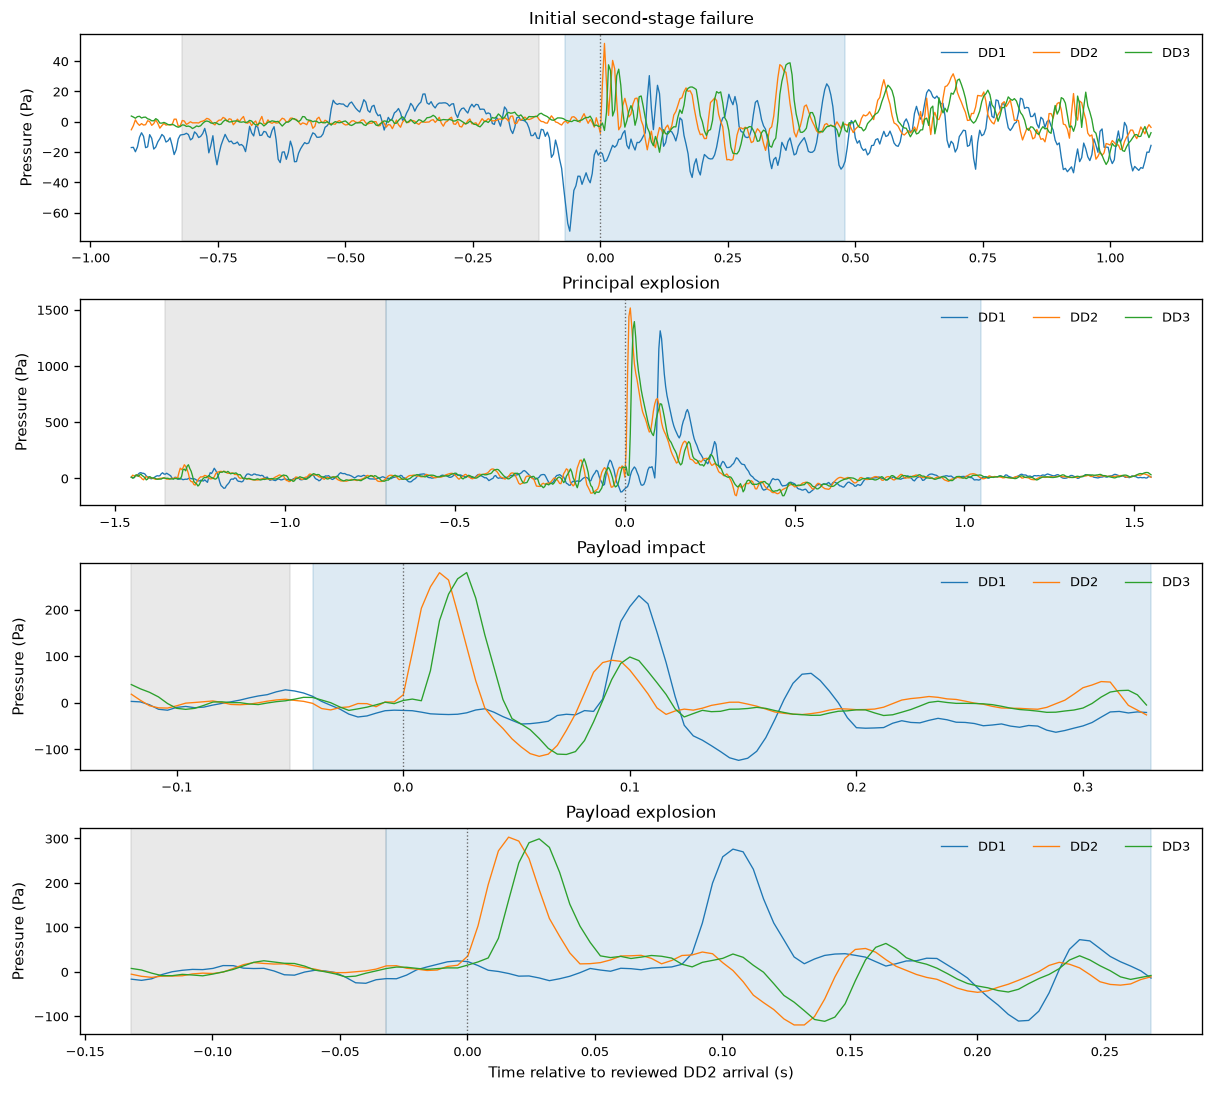

,source_event_key,event_number,named_signal_start_epoch_s,named_signal_end_epoch_s,catalogue_window_start_epoch_s,catalogue_window_end_epoch_s,pgv_vector_mps,pgv_peak_epoch_s,pgv_peak_within_named_signal,association
0,upper_stage,1,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,0.000133,1.472735e+09,True,overlapping measurement window; physical ident...
1,upper_stage,2,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,0.000078,1.472735e+09,True,overlapping measurement window; physical ident...
2,upper_stage,3,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,0.000136,1.472735e+09,True,overlapping measurement window; physical ident...
3,lower_stage,11,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,0.000658,1.472735e+09,True,overlapping measurement window; physical ident...
4,lower_stage,12,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,0.001156,1.472735e+09,True,overlapping measurement window; physical ident...
5,lower_stage,13,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,0.003575,1.472735e+09,True,overlapping measurement window; physical ident...
6,lower_stage,14,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,0.003405,1.472735e+09,True,overlapping measurement window; physical ident...
7,lower_stage,15,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,0.002707,1.472735e+09,True,overlapping measurement window; physical ident...
8,payload_impact,22,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,0.000698,1.472735e+09,True,overlapping measurement window; physical ident...
9,payload_explosion,23,1.472735e+09,1.472735e+09,1.472735e+09,1.472735e+09,0.000902,1.472735e+09,True,overlapping measurement window; physical ident...


,event,source_event_key,channel,actual_trace_start_epoch_s,sample_origin_minus_requested_start_s,sampling_rate_hz,baseline_sample_count,signal_sample_count,actual_baseline_first_epoch_s,actual_baseline_last_epoch_s,...,actual_signal_last_epoch_s,positive_peak_epoch_s,negative_peak_epoch_s,positive_peak_at_signal_edge,negative_peak_at_signal_edge,baseline_pa,pressure_squared_integral_before_local_baseline_pa2_s,pressure_squared_integral_after_local_baseline_pa2_s,local_baseline_integral_ratio,interval_convention
0,Initial second-stage failure,upper_stage,DD1,1.472735e+09,0.000066,250.0,175,138,1.472735e+09,1.472735e+09,...,1.472735e+09,1.472735e+09,1.472735e+09,False,False,9.656473,182.745467,273.614606,1.497244,relative to actual snapped trace start; baseli...
1,Initial second-stage failure,upper_stage,DD2,1.472735e+09,0.000066,250.0,175,138,1.472735e+09,1.472735e+09,...,1.472735e+09,1.472735e+09,1.472735e+09,False,False,0.198394,106.017689,105.564229,0.995723,relative to actual snapped trace start; baseli...
2,Initial second-stage failure,upper_stage,DD3,1.472735e+09,0.000066,250.0,175,138,1.472735e+09,1.472735e+09,...,1.472735e+09,1.472735e+09,1.472735e+09,False,False,0.034235,100.075891,100.005333,0.999295,relative to actual snapped trace start; baseli...
3,Principal explosion,lower_stage,DD1,1.472735e+09,-0.001235,250.0,163,438,1.472735e+09,1.472735e+09,...,1.472735e+09,1.472735e+09,1.472735e+09,False,False,-10.140813,59979.823210,61610.349185,1.027185,relative to actual snapped trace start; baseli...
4,Principal explosion,lower_stage,DD2,1.472735e+09,-0.001235,250.0,163,438,1.472735e+09,1.472735e+09,...,1.472735e+09,1.472735e+09,1.472735e+09,False,False,-7.748999,81515.726821,82976.065594,1.017915,relative to actual snapped trace start; baseli...
5,Principal explosion,lower_stage,DD3,1.472735e+09,-0.001235,250.0,163,438,1.472735e+09,1.472735e+09,...,1.472735e+09,1.472735e+09,1.472735e+09,False,False,-8.503335,70940.521510,72447.997604,1.021250,relative to actual snapped trace start; baseli...
6,Payload impact,payload_impact,DD1,1.472735e+09,0.000005,250.0,18,93,1.472735e+09,1.472735e+09,...,1.472735e+09,1.472735e+09,1.472735e+09,False,False,19.310221,1498.668444,1630.059168,1.087672,relative to actual snapped trace start; baseli...
7,Payload impact,payload_impact,DD2,1.472735e+09,0.000005,250.0,18,93,1.472735e+09,1.472735e+09,...,1.472735e+09,1.472735e+09,1.472735e+09,False,False,-3.182755,1732.439176,1751.689183,1.011112,relative to actual snapped trace start; baseli...
8,Payload impact,payload_impact,DD3,1.472735e+09,0.000005,250.0,18,93,1.472735e+09,1.472735e+09,...,1.472735e+09,1.472735e+09,1.472735e+09,False,False,9.283801,1806.297282,1734.498071,0.960251,relative to actual snapped trace start; baseli...
9,Payload explosion,payload_explosion,DD1,1.472735e+09,-0.001823,250.0,25,76,1.472735e+09,1.472735e+09,...,1.472735e+09,1.472735e+09,1.472735e+09,False,False,9.508688,1999.177099,1824.574721,0.912663,relative to actual snapped trace start; baseli...


In [5]:
fig, axes = plt.subplots(len(event_windows), 1, figsize=(10, 9), constrained_layout=True)
for ax, spec, stream in zip(axes, event_windows, event_streams):
    for tr in stream:
        measured = key_event_pressures.loc[(key_event_pressures.event == spec["event"]) & (key_event_pressures.channel == tr.stats.channel)].iloc[0]
        x = float(tr.stats.starttime - spec["reference_arrival"]) + tr.times()
        ax.plot(x, np.asarray(tr.data) - measured.baseline_pa, lw=0.8, label=tr.stats.channel)
        offset = float(tr.stats.starttime - spec["reference_arrival"])
        ax.axvspan(offset + spec["baseline_start_s"], offset + spec["baseline_end_s"], color="0.7", alpha=0.10)
        ax.axvspan(offset + spec["signal_start_s"], offset + spec["signal_end_s"], color="tab:blue", alpha=0.05)
    ax.axvline(0, color="0.4", ls=":", lw=0.8)
    ax.set_title(spec["event"])
    ax.set_ylabel("Pressure (Pa)")
    ax.legend(frameon=False, ncol=3)
axes[-1].set_xlabel("Time relative to reviewed DD2 arrival (s)")
fig.savefig(FIGURE_DIR / "key_event_window_review.pdf", bbox_inches="tight")
plt.show()

amplitude_file = config.NB070_DIR / "event_acoustic_seismic_amplitudes.csv"
association_rows = []
if amplitude_file.exists():
    catalogue = pd.read_csv(amplitude_file)
    required = {"event_number", "reduced_event_epoch_s", "seismic_signal_start_s", "seismic_signal_end_s", "pgv_vector_mps", "pgv_vector_time_s"}
    if not required.issubset(catalogue.columns) or catalogue.event_number.duplicated().any():
        raise ValueError("Incompatible Notebook 070 amplitude table")
    for spec in event_windows:
        channel_audit = sample_audit.loc[sample_audit.source_event_key.eq(spec["source_event_key"]) & sample_audit.channel.eq(REFERENCE_CHANNEL)].iloc[0]
        start, end = channel_audit.actual_signal_first_epoch_s, channel_audit.actual_signal_last_epoch_s
        catalogue_start = catalogue.reduced_event_epoch_s + catalogue.seismic_signal_start_s
        catalogue_end = catalogue.reduced_event_epoch_s + catalogue.seismic_signal_end_s
        for _, row in catalogue.loc[(catalogue_start <= end) & (catalogue_end >= start)].iterrows():
            association_rows.append({
                "source_event_key": spec["source_event_key"], "event_number": int(row.event_number),
                "named_signal_start_epoch_s": start, "named_signal_end_epoch_s": end,
                "catalogue_window_start_epoch_s": float(row.reduced_event_epoch_s + row.seismic_signal_start_s),
                "catalogue_window_end_epoch_s": float(row.reduced_event_epoch_s + row.seismic_signal_end_s),
                "pgv_vector_mps": float(row.pgv_vector_mps),
                "pgv_peak_epoch_s": float(row.reduced_event_epoch_s + row.pgv_vector_time_s),
                "pgv_peak_within_named_signal": bool(start <= row.reduced_event_epoch_s + row.pgv_vector_time_s <= end),
                "association": "overlapping measurement window; physical identity not established",
            })
    pd.DataFrame(association_rows).to_csv(DERIVED_DIR / "key_event_catalogue_pgv_overlap_audit.csv", index=False)
    display(pd.DataFrame(association_rows))
else:
    print("Notebook 070 amplitude table absent: optional PGV association audit skipped.")
display(sample_audit)


## Independent UCS-3 video timing versus BCHH arrivals

For quantitative source-event timing, all intervals below come from the **same UCS-3 remote camera**. No absolute synchronization between the camera and BCHH is assumed or required. The camera has 60-fps imagery but a burned-in 30-fps timecode, so each displayed timecode value occurs on two consecutive decoded frames. `member_60fps=1` and `2` preserve that distinction.

The measured quantity is

\[\Delta t_{\rm prop}=\Delta t_{\rm video}-\Delta t_{\rm BCHH},\]

where positive values mean that the later event required less propagation time to reach BCHH than the initial event.

In [6]:
video_frames = config.UCS3_VIDEO_EVENT_FRAMES.copy()
video_frames_used = video_frames.loc[video_frames["included_in_analysis"].astype(bool)].copy()

def median_bchh_interval(event):
    return config.bchh_median_pressure_interval_s("upper_stage", event)

rows = []
# Exact preferred timings for payload events; principal is bracketed by early/late frames.
for event, estimates in {
    "lower_stage": ("early_bound", "late_bound"),
    "payload_impact": ("preferred",),
    "payload_explosion": ("preferred",),
}.items():
    bchh_dt = median_bchh_interval(event)
    for estimate in estimates:
        video_dt = config.ucs3_video_interval_s(event, estimate=estimate)
        rows.append({
            "event": event,
            "video_estimate": estimate,
            "video_interval_from_upper_stage_s": video_dt,
            "bchh_median_interval_from_upper_stage_s": bchh_dt,
            "differential_propagation_advance_s": video_dt - bchh_dt,
        })

timing_comparison = pd.DataFrame(rows)
display(video_frames)
display(timing_comparison)

# Direct payload-pair consistency check.
payload_video_separation = (
    config.ucs3_video_interval_s("payload_explosion")
    - config.ucs3_video_interval_s("payload_impact")
)
payload_bchh_separation = float(np.median([
    config.bchh_pressure_interval_s("payload_impact", "payload_explosion", ch)
    for ch in ("DD2", "DD3")
]))
payload_pair_check = pd.DataFrame([{
    "video_payload_pair_separation_s": payload_video_separation,
    "bchh_payload_pair_separation_s": payload_bchh_separation,
    "video_minus_bchh_s": payload_video_separation - payload_bchh_separation,
}])
display(payload_pair_check)

timing_comparison.to_csv(DERIVED_DIR / "named_event_video_bchh_timing_comparison.csv", index=False)
payload_pair_check.to_csv(DERIVED_DIR / "payload_pair_timing_crosscheck.csv", index=False)

,event,estimate,timecode_hms,timecode_frame_30fps,member_60fps,included_in_analysis,timing_role,notes,camera_clock_s
0,upper_stage,alternate_bound,13:07:12,3,1,False,alternate_reference,Useful alternate reference bound; not the defa...,47232.100000
1,upper_stage,preferred,13:07:12,3,2,True,reference,Preferred initial-event reference from the sup...,47232.116667
2,lower_stage,early_bound,13:07:15,21,2,True,lower_bound,Earliest plausible principal-explosion frame; ...,47235.716667
3,lower_stage,late_bound,13:07:15,23,2,True,upper_bound,Latest plausible principal-explosion frame; 3....,47235.783333
4,payload_impact,excluded_candidate,13:07:24,15,2,False,excluded_candidate,Earlier payload candidate assessed as probably...,47244.516667
5,payload_impact,preferred,13:07:24,18,2,True,event,Preferred payload-impact pick from supplied me...,47244.616667
6,payload_explosion,preferred,13:07:25,6,1,True,event,Preferred payload-explosion pick from supplied...,47245.200000


,event,video_estimate,video_interval_from_upper_stage_s,bchh_median_interval_from_upper_stage_s,differential_propagation_advance_s
0,lower_stage,early_bound,3.600000,3.501014,0.098986
1,lower_stage,late_bound,3.666667,3.501014,0.165653
2,payload_impact,preferred,12.500000,12.480232,0.019768
3,payload_explosion,preferred,13.083333,13.060170,0.023163


,video_payload_pair_separation_s,bchh_payload_pair_separation_s,video_minus_bchh_s
0,0.583333,0.579938,0.003395


## Weak-shock timing sensitivity

This is a deliberately simple sensitivity calculation, not a source-pressure inversion. Measured positive pressure at BCHH is extrapolated inward with the existing $1/r$ model in `modules.physics`. The comparison of interest is the **differential** modeled advance relative to the initial event.

,event,median_positive_pressure_pa,local_mach_at_bchh,local_shock_speed_with_wind_mps,modeled_path_average_speed_with_wind_mps,modeled_advance_vs_linear_s,modeled_differential_advance_vs_upper_stage_s
0,upper_stage,38.837744,1.000164,351.034149,351.260388,0.003238,0.000000
1,lower_stage,1394.101001,1.005879,353.024870,359.818051,0.098594,0.095356
2,payload_impact,279.145109,1.001180,351.387961,352.947041,0.022398,0.019160
3,payload_explosion,299.098307,1.001264,351.417322,353.082528,0.023929,0.020691


,event,video_estimate,video_interval_from_upper_stage_s,bchh_median_interval_from_upper_stage_s,differential_propagation_advance_s,modeled_differential_advance_vs_upper_stage_s
0,lower_stage,early_bound,3.600000,3.501014,0.098986,0.095356
1,lower_stage,late_bound,3.666667,3.501014,0.165653,0.095356
2,payload_impact,preferred,12.500000,12.480232,0.019768,0.019160
3,payload_explosion,preferred,13.083333,13.060170,0.023163,0.020691


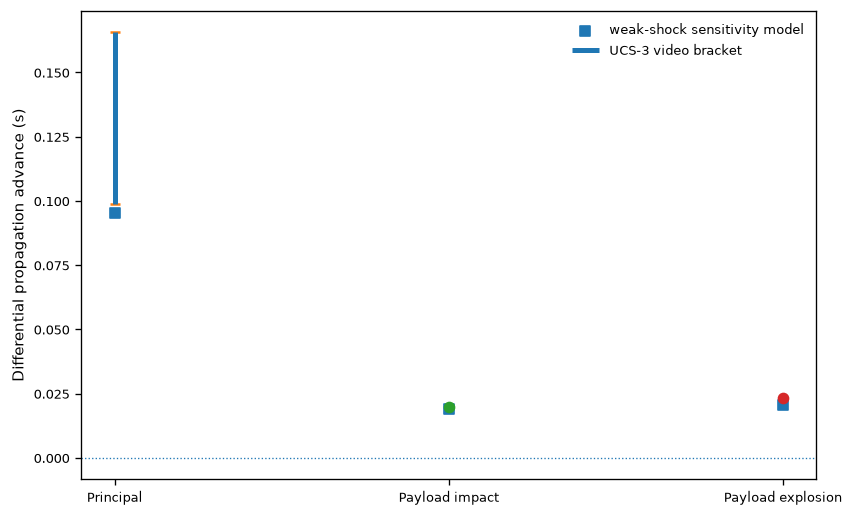

In [7]:
from modules.physics import mach_vs_overpressure

weather_file = config.NB020_DIR / "weather_acoustic_summary.csv"
if not weather_file.is_file():
    raise FileNotFoundError(f"Run Notebook 020 first: {weather_file}")
weather = pd.read_csv(weather_file).iloc[0]
still_air_c = float(weather["still_air_sound_speed_mps"])
wind_along = float(weather["wind_along_ray_mps"])
linear_effective_c = still_air_c + wind_along

# Use the median positive pressure across DD1/DD2/DD3 for each named event.
event_label_to_key = {spec["event"]: spec["source_event_key"] for spec in event_windows}
median_rows = key_event_pressures.loc[key_event_pressures["channel"].eq("MEDIAN")].copy()
pressure_by_key = {
    event_label_to_key[row.event]: float(row.positive_peak_pa)
    for row in median_rows.itertuples(index=False)
}

reference_distance_m = REFERENCE_CHANNEL_DISTANCE_M
model_rows = []
for key in required_source_events:
    p_pa = pressure_by_key[key]
    model = mach_vs_overpressure(
        speed_of_sound=still_air_c,
        ambient_pressure=101325.0,
        reference_distance=reference_distance_m,
        reference_overpressure=p_pa,
        minimum_model_distance=10.0,
        spreading_exponent=1.0,
    )
    # Keep the same transparent approximation used in the manuscript sensitivity:
    # add the measured path-parallel wind to the model path-average still-air speed.
    path_speed_with_wind = float(model["path_average_speed_mps"] + wind_along)
    linear_time = reference_distance_m / linear_effective_c
    shock_time = reference_distance_m / path_speed_with_wind
    model_rows.append({
        "event": key,
        "median_positive_pressure_pa": p_pa,
        "local_mach_at_bchh": float(model["mach_at_array"]),
        "local_shock_speed_with_wind_mps": float(model["local_speed_at_array_mps"] + wind_along),
        "modeled_path_average_speed_with_wind_mps": path_speed_with_wind,
        "modeled_advance_vs_linear_s": linear_time - shock_time,
    })
weak_shock_timing = pd.DataFrame(model_rows)
reference_advance = float(weak_shock_timing.loc[weak_shock_timing.event.eq("upper_stage"), "modeled_advance_vs_linear_s"].iloc[0])
weak_shock_timing["modeled_differential_advance_vs_upper_stage_s"] = (
    weak_shock_timing["modeled_advance_vs_linear_s"] - reference_advance
)

display(weak_shock_timing)
weak_shock_timing.to_csv(DERIVED_DIR / "named_event_weak_shock_timing_sensitivity.csv", index=False)

# Combine observations and model values for the three later events.
comparison = timing_comparison.merge(
    weak_shock_timing[["event", "modeled_differential_advance_vs_upper_stage_s"]],
    on="event", how="left", validate="many_to_one",
)
display(comparison)
comparison.to_csv(DERIVED_DIR / "named_event_observed_vs_modeled_timing.csv", index=False)

fig, ax = plt.subplots(figsize=(7.0, 4.2), constrained_layout=True)
plot_order = ["lower_stage", "payload_impact", "payload_explosion"]
x = np.arange(len(plot_order))
model_y = [float(weak_shock_timing.loc[weak_shock_timing.event.eq(k), "modeled_differential_advance_vs_upper_stage_s"].iloc[0]) for k in plot_order]
ax.scatter(x, model_y, marker="s", label="weak-shock sensitivity model")
for j,key in enumerate(plot_order):
    obs = comparison.loc[comparison.event.eq(key), "differential_propagation_advance_s"].to_numpy(float)
    if len(obs)==1:
        ax.scatter([j], obs, marker="o", label="UCS-3 video minus BCHH" if j==0 else None)
    elif len(obs)==2:
        ax.vlines(j, obs.min(), obs.max(), lw=3, label="UCS-3 video bracket" if j==0 else None)
        ax.scatter([j,j], obs, marker="_")
ax.axhline(0, lw=0.8, ls=":")
ax.set_xticks(x, ["Principal", "Payload impact", "Payload explosion"])
ax.set_ylabel("Differential propagation advance (s)")
ax.legend(frameon=False)
fig.savefig(DERIVED_DIR / "named_event_timing_observed_vs_weak_shock.pdf", bbox_inches="tight")
plt.show()